In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib_venn

# helper script module that incorporates pandas read-in and adding/separating fields
# copied over from 20230901, can eventually be shuttled off to its own special directory if it stays in use
import parsing_utils as parse

# Intersecting benchmarks with Sniffles output
See the long, long code block in `benchmark_comp_ins.ipynb` for more info. This notebook is mostly duplicated from there.

```
# intersect deletions
snakemake -pj40 --keep-going --use-conda -s Snakefile results/variant/intersect/caller+sniffles_mosaic+HG002_894_simulation/caller+giab_CMRG+HG002/szro-default/all/all/sv_del/intersect.tsv.gz results/variant/intersect/caller+sniffles_mosaic+HG002_894_simulation/caller+giab_SVTier1+HG002/szro-default/all/all/sv_del/intersect.tsv.gz results/variant/intersect/caller+sniffles_germline+HG002/caller+giab_CMRG+HG002/szro-default/all/all/sv_del/intersect.tsv.gz results/variant/intersect/caller+sniffles_germline+HG002/caller+giab_SVTier1+HG002/szro-default/all/all/sv_del/intersect.tsv.gz
cd ../..

# move the deletion intersect files to the current notebook directory
mv code/svpop/results/variant/intersect/caller+sniffles_mosaic+HG002_894_simulation/caller+giab_CMRG+HG002/szro-default/all/all/sv_del/intersect.tsv.gz notebooks/jupyter/20230915/simulation_giab_CMRG_CHM13_intersect_del.tsv.gz
mv code/svpop/results/variant/intersect/caller+sniffles_mosaic+HG002_894_simulation/caller+giab_SVTier1+HG002/szro-default/all/all/sv_del/intersect.tsv.gz notebooks/jupyter/20230915/simulation_giab_SVTier1_CHM13_intersect_del.tsv.gz
mv code/svpop/results/variant/intersect/caller+sniffles_germline+HG002/caller+giab_CMRG+HG002/szro-default/all/all/sv_del/intersect.tsv.gz notebooks/jupyter/20230915/germline_giab_CMRG_CHM13_intersect_del.tsv.gz
mv code/svpop/results/variant/intersect/caller+sniffles_germline+HG002/caller+giab_SVTier1+HG002/szro-default/all/all/sv_del/intersect.tsv.gz notebooks/jupyter/20230915/germline_giab_SVTier1_CHM13_intersect_del.tsv.gz

# make copies of the "standardized" variant IDs generated by svpop
cp code/svpop/results/variant/caller/giab_CMRG/HG002/all/all/bed/sv_del.bed.gz notebooks/jupyter/20230915/giab_CMRG_del_svpop.bed.gz
cp code/svpop/results/variant/caller/giab_SVTier1/HG002/all/all/bed/sv_del.bed.gz notebooks/jupyter/20230915/giab_SVTier1_del_svpop.bed.gz
cp code/svpop/results/variant/caller/sniffles_germline/HG002/all/all/bed/sv_del.bed.gz notebooks/jupyter/20230915/germline_del_svpop.bed.gz
cp code/svpop/results/variant/caller/sniffles_mosaic/HG002_894_simulation/all/all/bed/sv_del.bed.gz notebooks/jupyter/20230915/simulation_del_svpop.bed.gz
```

# Examining the benchmark files
Using the `svpop`-formatted bedfiles, because those have `SVTYPE` and `SVLEN` fields pre-populated.

## Deletions

In [2]:
svpop_CMRG_del = pd.read_table("giab_CMRG_del_svpop.bed.gz")
svpop_CMRG_del.head()

,#CHROM,POS,END,ID,SVTYPE,SVLEN,REF,ALT,QUAL,FILTER,VCF_ALT_IDX,VARTYPE,VCF_POS,VCF_REF,VCF_ALT,VCF_IDX
0,chr10,14926771,14926945,chr10-14926772-DEL-174,DEL,174,NaN,<DEL>,30,PASS,1,SV,14926771,TAATAGCTGGGACTACAGGTGCCCGCCACCACACCTGGCTAATTTT...,T,77
1,chr11,728094,728548,chr11-728095-DEL-454,DEL,454,NaN,<DEL>,30,PASS,1,SV,728094,CGGTGAAACCCCATCTCTACTAAAAATACAAAAATTAGCCGGGCAT...,C,70
2,chr14,99391728,99391780,chr14-99391729-DEL-52,DEL,52,NaN,<DEL>,30,PASS,1,SV,99391728,TGGGGAGGCAGGGTTGGGGGAGGTGGGGAAGGGGGTGGTAGGGAGG...,T,82
3,chr16,1383692,1383748,chr16-1383693-DEL-56,DEL,56,NaN,<DEL>,30,PASS,1,SV,1383692,ACCTGCGGCCCTCCCTCCCTCCCCTCCCATCTCACCCCCACACGCT...,A,88
4,chr16,95478651,95478712,chr16-95478652-DEL-61,DEL,61,NaN,<DEL>,30,PASS,1,SV,95478651,CTGAAGACTACCTGTGACCTCAGCACTCTAGGAGGCTGACATGAGG...,C,98


In [3]:
svpop_SVTier1_del = pd.read_table("giab_SVTier1_del_svpop.bed.gz")
svpop_SVTier1_del.head()

,#CHROM,POS,END,ID,SVTYPE,SVLEN,REF,ALT,QUAL,FILTER,VCF_ALT_IDX,VARTYPE,VCF_POS,VCF_REF,VCF_ALT,VCF_IDX
0,chr1,1101414,1101581,chr1-1101415-DEL-167,DEL,167,NaN,<DEL>,20,PASS,1,SV,1101414,ACACGCCTGTAATCCCAGCTACTTGGGAGGCTGAGGCAGGAGAATC...,A,61
1,chr1,1577122,1577207,chr1-1577123-DEL-85,DEL,85,NaN,<DEL>,20,PASS,1,SV,1577122,CAGCAGCCGAAGCGCCTCCTTTCAATCCAGGGTCCACACATCCAGC...,C,81
2,chr1,1697448,1697518,chr1-1697449-DEL-70,DEL,70,NaN,<DEL>,10,PASS,1,SV,1697448,TCTCCTGATCTCCTGATCTGGAAGGCGTGGAATCAGAGTTTGGGTG...,T,86
3,chr1,2272001,2272165,chr1-2272002-DEL-164,DEL,164,NaN,<DEL>,10,PASS,1,SV,2272001,TTGGAACAGAACTCCACACCCACAGGTGAGCATCTGACAGCCTGGA...,T,105
4,chr1,2450796,2450943,chr1-2450797-DEL-147,DEL,147,NaN,<DEL>,10,PASS,1,SV,2450796,TGTACGGCAGGGGTGGTGCTGGCAGCTCTGTGGCGGTGCCGGGCTG...,T,113


# Examining & annotating the simulation file
The `svpop`-formatted simulation bedfile needs to be annotated with the origin of each SV called by sniffles, as we did before with `RNAMES` in the direct-from-Sniffles VCF.

In [4]:
# I forgot that I gave svpop the input *without* censats removed, but you know what, it wasn't even that useful, so maybe that's fine.
# we don't need to run the filters here, we should have a sort of filter-agnostic approach when examining intersects with the benchmarks
# we could be surprised!

simulation_raw = parse.variant_table('/Users/stacyli/savio/global/scratch/stacy-l/spermSV/output/mapping/CHM13/sniffles/mosaic/single_sample/HG002_894_simulation.vcf.gz')
svpop_simulation_del = pd.read_table("simulation_del_svpop.bed.gz")

# annotate svpop_simulation_del with ORIGIN and RNAMES, using VCF_IDX as a key to match index values of simulation_raw VCF
svpop_simulation_del = pd.merge(svpop_simulation_del, simulation_raw[['ORIGIN', 'RNAMES']], left_on = 'VCF_IDX', right_index = True)
svpop_simulation_del.head()

,#CHROM,POS,END,ID,SVTYPE,SVLEN,REF,ALT,QUAL,FILTER,VCF_ALT_IDX,VARTYPE,VCF_POS,VCF_REF,VCF_ALT,VCF_IDX,ORIGIN,RNAMES
0,chr1,92624,92701,chr1-92625-DEL-77,DEL,77,NaN,<DEL>,60,PASS,1,SV,92624,accatcaggacaaacacgtgggtacatggaggggaacaacacacac...,N,2,894,894/34931686/ccs
1,chr1,93068,93144,chr1-93069-DEL-76,DEL,76,NaN,<DEL>,60,PASS,1,SV,93068,ggggacagggggtaggagaccatcaggacaaacacgtggatacatg...,N,3,894,894/34931686/ccs
2,chr1,215586,215638,chr1-215587-DEL-52,DEL,52,NaN,<DEL>,60,PASS,1,SV,215586,gcaatggaatgcattggaatggaatgcaatggacttgaatgggatg...,N,4,894,894/148115362/ccs
3,chr1,218571,218642,chr1-218572-DEL-71,DEL,71,NaN,<DEL>,60,PASS,1,SV,218571,tcgaaaggaatggaatggaatggaatggaatggaatggaatggaat...,N,5,894,894/134088549/ccs
4,chr1,218804,218870,chr1-218805-DEL-66,DEL,66,NaN,<DEL>,60,PASS,1,SV,218804,aatggaatcgacccgaatggaatggaatggaatggaatggaatgga...,N,6,894,894/134088549/ccs


# Examining and annotating the germline file
Same deal as above: we're not so much interested in `ORIGIN`, only `RNAMES` for the sake of having insight into how SVs were called by `sniffles`.

In [5]:
germline_raw = parse.variant_table('/Users/stacyli/savio/global/scratch/stacy-l/spermSV/output/mapping/CHM13/sniffles/standard/single_sample/HG002.vcf.gz')
svpop_germline_del = pd.read_table("germline_del_svpop.bed.gz")

# annotate svpop_germline_del with ORIGIN and RNAMES, using VCF_IDX as a key to match index values of simulation_raw VCF
svpop_germline_del = pd.merge(svpop_germline_del, germline_raw[['ORIGIN', 'RNAMES']], left_on = 'VCF_IDX', right_index = True)
svpop_germline_del.head()

,#CHROM,POS,END,ID,SVTYPE,SVLEN,REF,ALT,QUAL,FILTER,VCF_ALT_IDX,VARTYPE,VCF_POS,VCF_REF,VCF_ALT,VCF_IDX,ORIGIN,RNAMES
0,chr1,3635,3697,chr1-3636-DEL-62,DEL,62,NaN,<DEL>,60,PASS,1,SV,3635,ccctcttgctcacagtgtagtggcagcacgcccgcctgctggcagc...,N,0,HG002,"HG002/235082663/ccs,HG002/30807480/ccs,HG002/1..."
1,chr1,4729,5066,chr1-4730-DEL-337,DEL,337,NaN,<DEL>,57,PASS,1,SV,4729,cacacaactaatcactcaaaatcatccttacactaaaaatgctaaa...,N,1,HG002,"HG002/210634283/ccs,HG002/142151040/ccs,HG002/..."
2,chr1,11670,11729,chr1-11671-DEL-59,DEL,59,NaN,<DEL>,60,PASS,1,SV,11670,GTCCCTCTGTCTCTGCCAACCAGTTAACCTGCTGCTTCCTGGAGGG...,N,2,HG002,"HG002/235082663/ccs,HG002/30807480/ccs,HG002/1..."
3,chr1,24101,25229,chr1-24102-DEL-1128,DEL,1128,NaN,<DEL>,60,PASS,1,SV,24101,catcttacacagcaatgaggcacgtgtggaaactgcgacactcaca...,N,4,HG002,"HG002/55710083/ccs,HG002/141100667/ccs,HG002/1..."
4,chr1,24617,25134,chr1-24618-DEL-517,DEL,517,NaN,<DEL>,60,PASS,1,SV,24617,TGGGTGCCATCTCAGCAGCTCACGGTGTGGAAACTGCGACACTCAC...,N,5,HG002,"HG002/51249976/ccs,HG002/239342140/ccs,HG002/1..."


# Examining the intersection files
Time to look at everything!

For all files, `ID_A` refers to the ID in the simulation/germline query file, and `ID_B` is the ID in the benchmark. All intersects are test examinations of **insertions only**.

## Germline HG002 calls <-> GIAB CMRG

In [6]:
germline_giab_CMRG_intersect_del_all = pd.read_table("germline_giab_CMRG_CHM13_intersect_del.tsv.gz")

# filter to only intersected variants + merge with select columns from svpop_germline_del using ID_A as a key
germline_giab_CMRG_intersect_del = pd.merge(germline_giab_CMRG_intersect_del_all.query("SOURCE_SET == 'A,B'"), svpop_germline_del[['ID', 'SVTYPE', 'SVLEN', 'ORIGIN', 'RNAMES']], left_on = 'ID_A', right_on = 'ID')
print('Total intersected:', germline_giab_CMRG_intersect_del.shape[0], "/", svpop_CMRG_del.shape[0])

Total intersected: 31 / 32


## Germline HG002 calls <-> GIAB SV Tier 1

In [7]:
germline_giab_SVTier1_intersect_del_all = pd.read_table("germline_giab_SVTier1_CHM13_intersect_del.tsv.gz")

# filter to only intersected variants + merge with select columns from svpop_germline_del using ID_A as a key
germline_giab_SVTier1_intersect_del = pd.merge(germline_giab_SVTier1_intersect_del_all.query("SOURCE_SET == 'A,B'"), svpop_germline_del[['ID', 'SVTYPE', 'SVLEN', 'ORIGIN', 'RNAMES']], left_on = 'ID_A', right_on = 'ID')
print('Total intersected:', germline_giab_SVTier1_intersect_del.shape[0], "/", svpop_SVTier1_del.shape[0])

Total intersected: 1244 / 1451


## Simulation <-> GIAB CMRG

In [8]:
simulation_giab_CMRG_intersect_del_all = pd.read_table("simulation_giab_CMRG_CHM13_intersect_del.tsv.gz")

# filter to only intersected variants + merge with select columns from svpop_simulation_del using ID_A as a key
# finally, query to filter out only HG002 calls
simulation_giab_CMRG_intersect_del = pd.merge(simulation_giab_CMRG_intersect_del_all.query("SOURCE_SET == 'A,B'"), svpop_simulation_del[['ID', 'SVTYPE', 'SVLEN', 'ORIGIN', 'RNAMES']], left_on = 'ID_A', right_on = 'ID').query("ORIGIN == 'HG002'")
print('Total intersected:', simulation_giab_CMRG_intersect_del.shape[0], "/", svpop_CMRG_del.shape[0])


Total intersected: 5 / 32


In [9]:
# How many of the simulation's "true calls" also found in the germline sample's "true calls"?
# Below, take the intersection table above and use the benchmark's IDs ("ID_B") as a key to search for outcomes in the germline-benchmark intersection table.
germline_giab_CMRG_intersect_del.set_index('ID_B').loc[simulation_giab_CMRG_intersect_del['ID_B']].query(("SOURCE_SET == 'A,B'"))

,ID_A,SOURCE_SET,RO,OFFSET,SZRO,OFFSZ,MATCH,ID,SVTYPE,SVLEN,ORIGIN,RNAMES
ID_B,,,,,,,,,,,,
chr10-14926772-DEL-174,chr10-14926773-DEL-174,"A,B",0.99,1.0,1.0,0.01,NaN,chr10-14926773-DEL-174,DEL,174,HG002,"HG002/7276990/ccs,HG002/11928140/ccs,HG002/135..."
chr4-190006502-DEL-60,chr4-190006592-DEL-60,"A,B",0.00,90.0,1.0,1.50,NaN,chr4-190006592-DEL-60,DEL,60,HG002,"HG002/19008817/ccs,HG002/7603692/ccs,HG002/130..."
chr4-190040062-DEL-328,chr4-190040063-DEL-328,"A,B",1.00,1.0,1.0,0.00,NaN,chr4-190040063-DEL-328,DEL,328,HG002,"HG002/14160657/ccs,HG002/189202931/ccs,HG002/8..."
chr6-169831948-DEL-98,chr6-169831949-DEL-98,"A,B",0.99,1.0,1.0,0.01,NaN,chr6-169831949-DEL-98,DEL,98,HG002,"HG002/115475494/ccs,HG002/176293379/ccs,HG002/..."
chr9-140563804-DEL-150,chr9-140563805-DEL-150,"A,B",0.99,1.0,1.0,0.01,NaN,chr9-140563805-DEL-150,DEL,150,HG002,"HG002/188549485/ccs,HG002/6751847/ccs,HG002/11..."


## Simulation <-> GIAB SV Tier 1 ("high confidence" SV callset)

In [10]:
simulation_giab_SVTier1_intersect_del_all = pd.read_table("simulation_giab_SVTier1_CHM13_intersect_del.tsv.gz")

# filter to only intersected variants + merge with select columns from svpop_simulation_del using ID_A as a key
# finally, query to filter out only HG002 calls
simulation_giab_SVTier1_intersect_del = pd.merge(simulation_giab_SVTier1_intersect_del_all.query("SOURCE_SET == 'A,B'"), svpop_simulation_del[['ID', 'SVTYPE', 'SVLEN', 'ORIGIN', 'RNAMES']], left_on = 'ID_A', right_on = 'ID').query("ORIGIN == 'HG002'")
print('Total intersected:', simulation_giab_SVTier1_intersect_del.shape[0], "/", svpop_SVTier1_del.shape[0])

Total intersected: 209 / 1451


In [11]:
# How many of the simulation's "true calls" also found in the germline sample's "true calls"?
# Below, take the intersection table above and use the benchmark's IDs ("ID_B") as a key to search for outcomes in the germline-benchmark intersection table.

germline_giab_SVTier1_intersect_del.set_index('ID_B').loc[simulation_giab_SVTier1_intersect_del['ID_B']]

,ID_A,SOURCE_SET,RO,OFFSET,SZRO,OFFSZ,MATCH,ID,SVTYPE,SVLEN,ORIGIN,RNAMES
ID_B,,,,,,,,,,,,
chr1-3251086-DEL-72,chr1-3251087-DEL-72,"A,B",0.99,1.0,1.00,0.01,NaN,chr1-3251087-DEL-72,DEL,72,HG002,"HG002/76416257/ccs,HG002/46401625/ccs,HG002/34..."
chr1-3311974-DEL-150,chr1-3312036-DEL-150,"A,B",0.59,62.0,1.00,0.41,NaN,chr1-3312036-DEL-150,DEL,150,HG002,"HG002/59446681/ccs,HG002/184423528/ccs,HG002/1..."
chr1-8844936-DEL-54,chr1-8844937-DEL-54,"A,B",0.98,1.0,1.00,0.02,NaN,chr1-8844937-DEL-54,DEL,54,HG002,"HG002/91557139/ccs,HG002/44765408/ccs,HG002/12..."
chr1-12943294-DEL-190,chr1-12943392-DEL-189,"A,B",0.48,97.0,0.99,0.51,NaN,chr1-12943392-DEL-189,DEL,189,HG002,"HG002/67834269/ccs,HG002/139199309/ccs,HG002/1..."
chr1-48962833-DEL-54,chr1-48962834-DEL-54,"A,B",0.98,1.0,1.00,0.02,NaN,chr1-48962834-DEL-54,DEL,54,HG002,"HG002/195498149/ccs,HG002/55776481/ccs,HG002/1..."
...,...,...,...,...,...,...,...,...,...,...,...,...
chr9-146510718-DEL-81,chr9-146510719-DEL-81,"A,B",0.99,1.0,1.00,0.01,NaN,chr9-146510719-DEL-81,DEL,81,HG002,"HG002/79104308/ccs,HG002/223286194/ccs,HG002/2..."
chrX-33289840-DEL-200,chrX-33289841-DEL-200,"A,B",0.99,1.0,1.00,0.01,NaN,chrX-33289841-DEL-200,DEL,200,HG002,"HG002/114692435/ccs,HG002/204018030/ccs,HG002/..."
chrX-125818747-DEL-55,chrX-125818748-DEL-55,"A,B",0.98,1.0,1.00,0.02,NaN,chrX-125818748-DEL-55,DEL,55,HG002,"HG002/44174520/ccs,HG002/85593389/ccs,HG002/20..."


Unlike the insertion intersect results, it looks like *all* of the deletions found in the simulation's true calls are also IDed in the germline true calls. Nice?

# Plotting the distribution of true calls

## SV Tier 1 benchmarking

Only looking at the available calls in SV Tier 1. Excludes the large majority of ??? calls (only in germline/simulation callset) that weren't filtered and may be 1) erroneous, or 2) in the un-lifted off SV Tier 1 callset.

Text(0.5, 0.98, 'Intersection with SV Tier 1 benchmark (liftover to CHM13)')

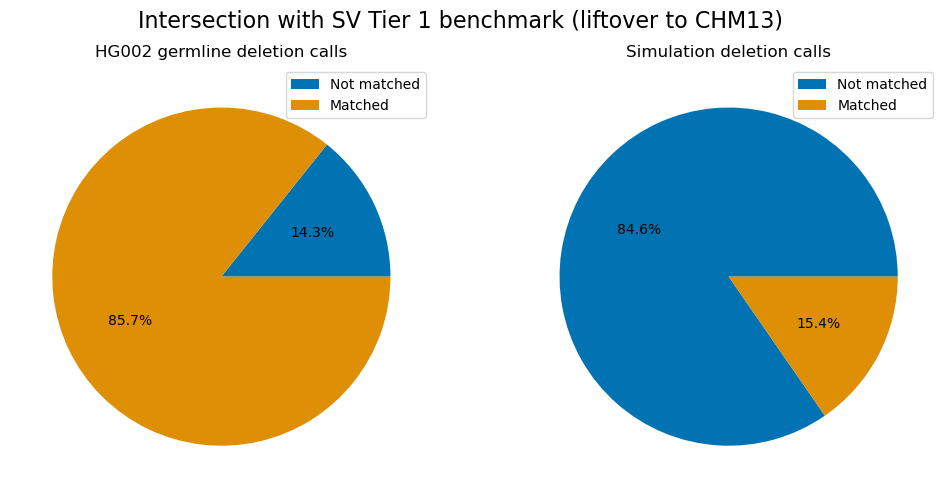

In [55]:
sns.set_style()
fig, ax = plt.subplots(ncols = 2, figsize = (12, 5.5))
ax[0].pie(germline_giab_SVTier1_intersect_del_all.groupby('SOURCE_SET').size().loc[[',B', 'A,B']], autopct='%1.1f%%', colors = sns.color_palette("colorblind"))
ax[0].set_title("HG002 germline deletion calls", size = 12)
ax[0].legend(labels = ["Not matched", "Matched"])
ax[1].pie(simulation_giab_SVTier1_intersect_del_all.groupby('SOURCE_SET').size().loc[[',B', 'A,B']], autopct='%1.1f%%', colors = sns.color_palette("colorblind"))
ax[1].set_title("Simulation deletion calls", size = 12)
ax[1].legend(labels = ["Not matched", "Matched"])
plt.suptitle("Intersection with SV Tier 1 benchmark (liftover to CHM13)", size = 16)

## CMRG benchmarking

Only looking at the available calls in CMRG. Excludes the large majority of ??? calls (only in germline/simulation callset) that weren't filtered and may be 1) erroneous, or 2) in the un-lifted off CMRG callset.

Text(0.5, 0.98, 'Intersection with CMRG benchmark (liftover to CHM13)')

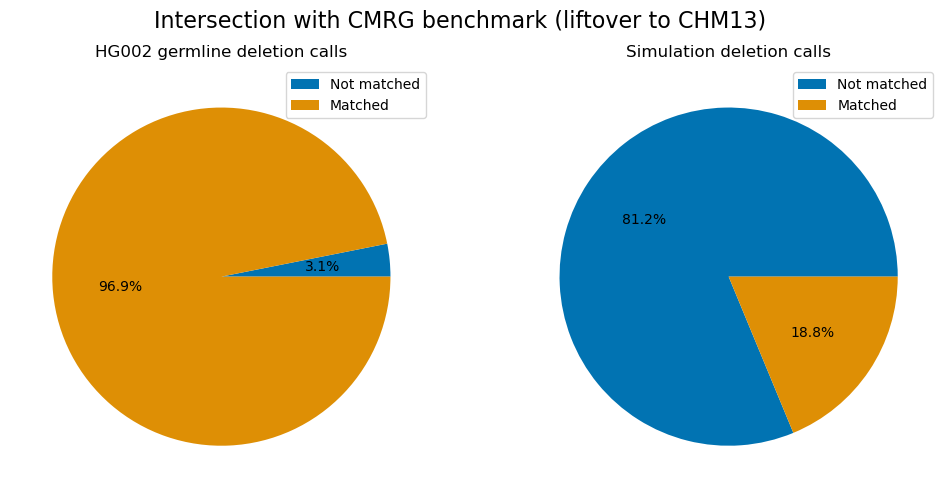

In [56]:
sns.set_style()
fig, ax = plt.subplots(ncols = 2, figsize = (12, 5.5))
ax[0].pie(germline_giab_CMRG_intersect_del_all.groupby('SOURCE_SET').size().loc[[',B', 'A,B']], autopct='%1.1f%%', colors = sns.color_palette("colorblind"))
ax[0].set_title("HG002 germline deletion calls", size = 12)
ax[0].legend(labels = ["Not matched", "Matched"])
ax[1].pie(simulation_giab_CMRG_intersect_del_all.groupby('SOURCE_SET').size().loc[[',B', 'A,B']], autopct='%1.1f%%', colors = sns.color_palette("colorblind"))
ax[1].set_title("Simulation deletion calls", size = 12)
ax[1].legend(labels = ["Not matched", "Matched"])
plt.suptitle("Intersection with CMRG benchmark (liftover to CHM13)", size = 16)